## Denoising Autoencoder on Fashion-MNIST

In this notebook, we build a **Denoising Autoencoder** using Fashion-MNIST.

A normal autoencoder learns:

`clean image → reconstructed clean image`

A denoising autoencoder learns:

`noisy image → reconstructed clean image`

This means the model receives a corrupted image as input, but it is trained to recover the original clean version.

### Practical goal

We will:

- load Fashion-MNIST images,
- normalise pixel values,
- add controlled random noise,
- split the data properly into train, validation, and test sets,
- train a convolutional denoising autoencoder,
- compare clean, noisy, and denoised images,
- calculate reconstruction error,
- write a clear final interpretation.

In [1]:
# ============================================================
# Step 1: Import Libraries and Check Environment
# ============================================================

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

import tensorflow as tf
from tensorflow import keras
from tensorflow.keras import layers

# Reproducibility
np.random.seed(42)
tf.random.set_seed(42)

print("TensorFlow version:", tf.__version__)
print("NumPy version:", np.__version__)

gpus = tf.config.list_physical_devices("GPU")
print("GPU available:", len(gpus) > 0)

if gpus:
    print("GPU device:", gpus[0].name)
else:
    print("Running on CPU")

2026-06-06 23:01:59.308803: I tensorflow/core/platform/cpu_feature_guard.cc:210] This TensorFlow binary is optimized to use available CPU instructions in performance-critical operations.
To enable the following instructions: AVX2 FMA, in other operations, rebuild TensorFlow with the appropriate compiler flags.


TensorFlow version: 2.16.2
NumPy version: 1.26.4
GPU available: False
Running on CPU


## 1. Load and Inspect Fashion-MNIST

Fashion-MNIST contains grayscale clothing images such as shirts, trousers, shoes, bags, and coats.

Each image has shape:

`28 × 28`

In this denoising notebook:

| Data version | Role |
|---|---|
| **Noisy image** | Model input |
| **Clean image** | Target output |

### Theory connection

The model should learn:

`noisy image → clean image`

So the model must learn the real object structure and ignore random noise.

In [2]:
# ============================================================
# Step 2: Load and Inspect Fashion-MNIST
# ============================================================

# Load Fashion-MNIST from Keras
# Source: Keras provides train/test images and labels
# Logic: labels are used only for interpretation, not for training

(x_train, y_train), (x_test, y_test) = keras.datasets.fashion_mnist.load_data()

# Class names for plot titles
class_names = [
    "T-shirt/top", "Trouser", "Pullover", "Dress", "Coat",
    "Sandal", "Shirt", "Sneaker", "Bag", "Ankle boot"
]

print("Training images shape:", x_train.shape)
print("Training labels shape:", y_train.shape)
print("Test images shape:", x_test.shape)
print("Test labels shape:", y_test.shape)

print("\nPixel value range before preprocessing:")
print("Minimum pixel value:", x_train.min())
print("Maximum pixel value:", x_train.max())

print("\nFirst 10 training labels:")
for label in y_train[:10]:
    print(label, "→", class_names[label])

Training images shape: (60000, 28, 28)
Training labels shape: (60000,)
Test images shape: (10000, 28, 28)
Test labels shape: (10000,)

Pixel value range before preprocessing:
Minimum pixel value: 0
Maximum pixel value: 255

First 10 training labels:
9 → Ankle boot
0 → T-shirt/top
0 → T-shirt/top
3 → Dress
0 → T-shirt/top
2 → Pullover
7 → Sneaker
2 → Pullover
5 → Sandal
5 → Sandal


### Dataset Loading — Conclusion

Fashion-MNIST was loaded successfully.

The dataset contains **28 × 28 grayscale images** with pixel values from **0 to 255** before preprocessing.

For denoising, we will create noisy versions of the same images and train the model to reconstruct the clean originals.

## 2. Visualise Clean Fashion-MNIST Images

Before adding noise, we inspect clean images first.

This gives us a reference point for later comparison:

`clean image → noisy image → denoised reconstruction`

### Theory connection

A denoising autoencoder should learn the important image structure, such as shoe outlines, trouser shapes, sleeves, and bag shapes.

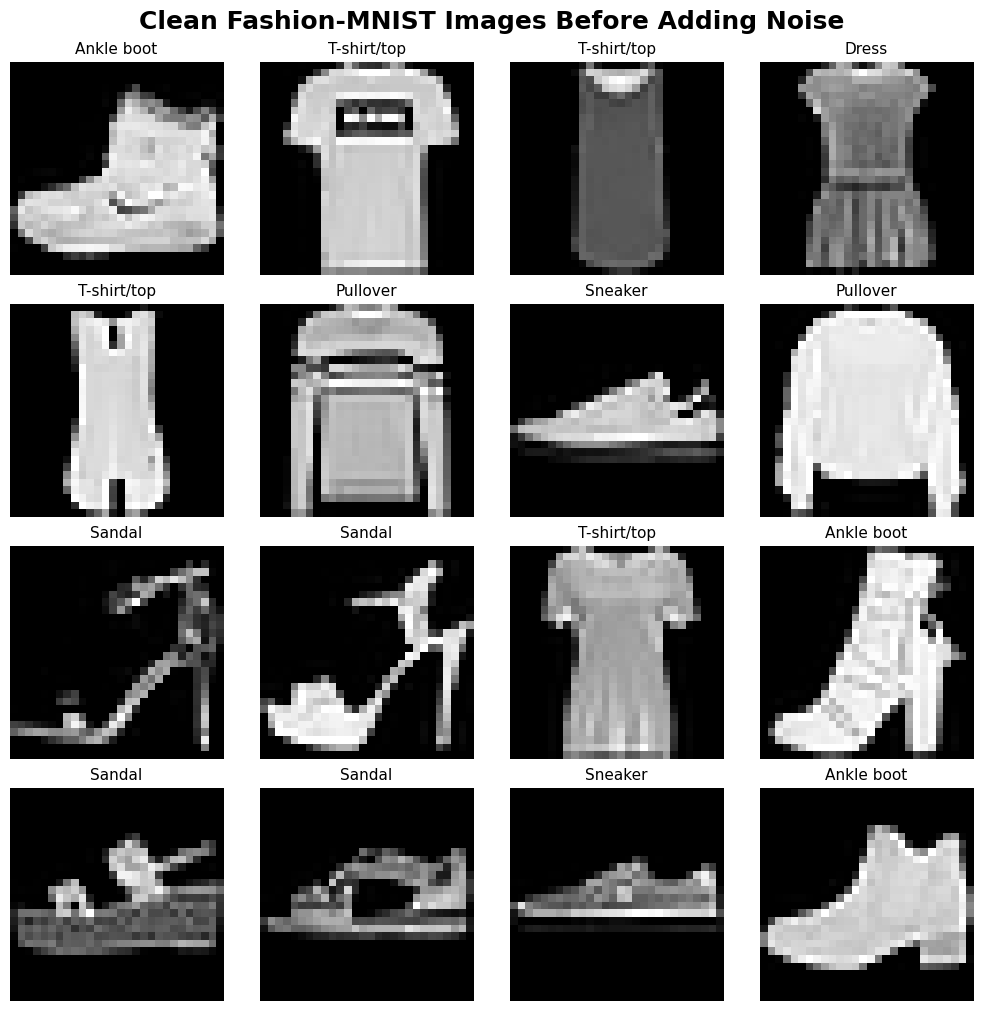

Single clean image shape: (28, 28)
Single clean image data type: uint8
Pixel range in first clean image: 0 to 255


In [3]:
# ============================================================
# Step 3: Visualise Clean Sample Images
# ============================================================

num_images = 16

# Source: x_train and y_train come from the loading step
# Logic: inspect clean images before adding noise

sample_images = x_train[:num_images]
sample_labels = y_train[:num_images]

fig, axes = plt.subplots(
    nrows=4,
    ncols=4,
    figsize=(10, 10),
    constrained_layout=True
)

fig.suptitle(
    "Clean Fashion-MNIST Images Before Adding Noise",
    fontsize=18,
    fontweight="bold"
)

for ax, image, label in zip(axes.ravel(), sample_images, sample_labels):
    ax.imshow(image, cmap="gray")
    ax.set_title(class_names[label], fontsize=11)
    ax.axis("off")

plt.show()

print("Single clean image shape:", sample_images[0].shape)
print("Single clean image data type:", sample_images[0].dtype)
print("Pixel range in first clean image:", sample_images[0].min(), "to", sample_images[0].max())

### Clean Image Inspection — Conclusion

The clean sample images show clear clothing and footwear structures.

These clean images will be used as the **target output** during denoising training.

Next, we create noisy versions of these images so the model can learn how to remove corruption.

## 3. Normalise Images and Add Noise

A denoising autoencoder needs two versions of each image:

| Version | Meaning |
|---|---|
| **Clean image** | Correct target image |
| **Noisy image** | Corrupted input image |

We first normalise pixel values from **0–255** to **0–1**.

Then we add random Gaussian noise.

### Theory connection

The model should learn that random noise is not important.  
The important information is the underlying clothing structure.

In [4]:
# ============================================================
# Step 4: Normalise Images and Create Noisy Images
# ============================================================

# Clean images
# Source: x_train / x_test from Fashion-MNIST
# Logic: normalise pixels to 0–1 because neural networks train better in small ranges
x_train_clean = x_train.astype("float32") / 255.0
x_test_clean = x_test.astype("float32") / 255.0

# Add channel dimension for Conv2D
# Flow: (samples, 28, 28) → (samples, 28, 28, 1)
x_train_clean = np.expand_dims(x_train_clean, axis=-1)
x_test_clean = np.expand_dims(x_test_clean, axis=-1)

# Noise strength
noise_factor = 0.35

# Noisy images
# Flow: clean image + random noise → noisy image
x_train_noisy = x_train_clean + noise_factor * np.random.normal(
    loc=0.0,
    scale=1.0,
    size=x_train_clean.shape
)

x_test_noisy = x_test_clean + noise_factor * np.random.normal(
    loc=0.0,
    scale=1.0,
    size=x_test_clean.shape
)

# Keep pixel values valid
x_train_noisy = np.clip(x_train_noisy, 0.0, 1.0)
x_test_noisy = np.clip(x_test_noisy, 0.0, 1.0)

print("Clean training shape:", x_train_clean.shape)
print("Noisy training shape:", x_train_noisy.shape)
print("Clean test shape:", x_test_clean.shape)
print("Noisy test shape:", x_test_noisy.shape)

print("\nClean pixel range:", x_train_clean.min(), "to", x_train_clean.max())
print("Noisy pixel range:", x_train_noisy.min(), "to", x_train_noisy.max())

Clean training shape: (60000, 28, 28, 1)
Noisy training shape: (60000, 28, 28, 1)
Clean test shape: (10000, 28, 28, 1)
Noisy test shape: (10000, 28, 28, 1)

Clean pixel range: 0.0 to 1.0
Noisy pixel range: 0.0 to 1.0


### Noise Creation — Conclusion

The clean and noisy image sets were created successfully.

Both versions have shape:

`28 × 28 × 1`

The denoising setup is now:

`noisy image → model → clean image`

## 4. Create Train, Validation, and Test Sets

We now separate the data properly.

| Set | Purpose |
|---|---|
| **Train** | Model learns from this |
| **Validation** | Model checks performance during training |
| **Test** | Final unseen evaluation after training |

### Important

Validation data does **not** update model weights.  
Test data is kept separate until final evaluation.

In [5]:
# ============================================================
# Step 5: Create Train, Validation, and Test Sets
# ============================================================

# Train = model learns from this
train_noisy = x_train_noisy[:10000]
train_clean = x_train_clean[:10000]

# Validation = checks during training, no weight update
val_noisy = x_train_noisy[10000:12000]
val_clean = x_train_clean[10000:12000]

# Test = final unseen evaluation
test_noisy = x_test_noisy[:2000]
test_clean = x_test_clean[:2000]
test_labels = y_test[:2000]

# Safety checks
assert train_noisy.shape[0] > 0, "Training set is empty."
assert val_noisy.shape[0] > 0, "Validation set is empty."
assert test_noisy.shape[0] > 0, "Test set is empty."

print("Train noisy:", train_noisy.shape)
print("Train clean:", train_clean.shape)

print("\nValidation noisy:", val_noisy.shape)
print("Validation clean:", val_clean.shape)

print("\nTest noisy:", test_noisy.shape)
print("Test clean:", test_clean.shape)

Train noisy: (10000, 28, 28, 1)
Train clean: (10000, 28, 28, 1)

Validation noisy: (2000, 28, 28, 1)
Validation clean: (2000, 28, 28, 1)

Test noisy: (2000, 28, 28, 1)
Test clean: (2000, 28, 28, 1)


## 5. Visualise Clean vs Noisy Images

Before training, we compare clean images with their noisy versions.

### Theory connection

The model will receive the noisy image as input and learn to reconstruct the clean image.

So the learning task is:

`remove noise while preserving object structure`

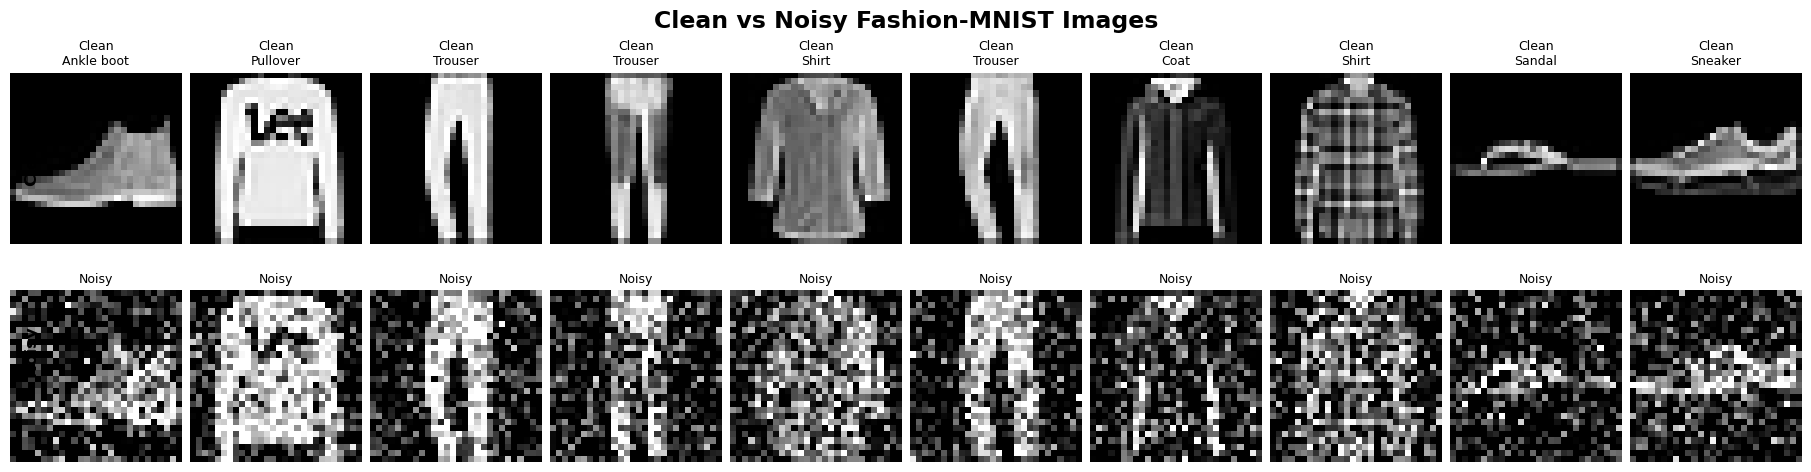

In [6]:
# ============================================================
# Step 6: Visualise Clean vs Noisy Images
# ============================================================

num_images = 10

# Source: test_clean and test_noisy come from the final test split
# Logic: compare the same images before and after noise was added
clean_samples = test_clean[:num_images]
noisy_samples = test_noisy[:num_images]
sample_labels = test_labels[:num_images]

fig, axes = plt.subplots(
    nrows=2,
    ncols=num_images,
    figsize=(18, 4.8),
    constrained_layout=True
)

fig.suptitle(
    "Clean vs Noisy Fashion-MNIST Images",
    fontsize=17,
    fontweight="bold"
)

for i in range(num_images):
    axes[0, i].imshow(clean_samples[i].squeeze(), cmap="gray")
    axes[0, i].set_title(f"Clean\n{class_names[sample_labels[i]]}", fontsize=9)
    axes[0, i].axis("off")

for i in range(num_images):
    axes[1, i].imshow(noisy_samples[i].squeeze(), cmap="gray")
    axes[1, i].set_title("Noisy", fontsize=9)
    axes[1, i].axis("off")

fig.text(0.01, 0.68, "Clean", fontsize=12, fontweight="bold", rotation=90, va="center")
fig.text(0.01, 0.28, "Noisy", fontsize=12, fontweight="bold", rotation=90, va="center")

plt.show()

### Clean vs Noisy Image Comparison — Conclusion

The noisy images contain strong random pixel corruption.

However, the main clothing shapes are still partly visible. This makes the denoising task meaningful.

The model must learn:

`noise is not important → object structure is important`

## 6. Build the Convolutional Denoising Autoencoder

We now build a convolutional autoencoder for denoising.

The architecture follows this pattern:

`noisy image → encoder → bottleneck → decoder → clean reconstructed image`

| Input to model | Target output |
|---|---|
| Noisy image | Clean image |

### Theory connection

The encoder compresses the noisy image into important visual features.  
The decoder reconstructs the clean image from those features.

This forces the model to keep useful structure and remove random noise.

In [7]:
# ============================================================
# Step 7: Build and Compile the Denoising Autoencoder
# ============================================================

# Input placeholder
# Note: this is not actual data yet.
# It tells Keras that noisy images with shape 28 × 28 × 1 will enter here during training.
input_img = keras.Input(
    shape=(28, 28, 1),
    name="noisy_image_input"
)

# Encoder: noisy image → learned feature maps
x = layers.Conv2D(
    32,
    kernel_size=(3, 3),
    activation="relu",
    padding="same",
    name="encoder_conv_32"
)(input_img)

# Encoder: feature maps → smaller spatial representation
x = layers.MaxPooling2D(
    pool_size=(2, 2),
    padding="same",
    name="encoder_pool_1"
)(x)

# Encoder: smaller maps → deeper features
x = layers.Conv2D(
    16,
    kernel_size=(3, 3),
    activation="relu",
    padding="same",
    name="encoder_conv_16"
)(x)

# Bottleneck: compressed representation of the noisy image
encoded = layers.MaxPooling2D(
    pool_size=(2, 2),
    padding="same",
    name="bottleneck_7x7x16"
)(x)

# Decoder: bottleneck → feature maps
x = layers.Conv2D(
    16,
    kernel_size=(3, 3),
    activation="relu",
    padding="same",
    name="decoder_conv_16"
)(encoded)

# Decoder: increase size from 7 × 7 to 14 × 14
x = layers.UpSampling2D(
    size=(2, 2),
    name="decoder_upsample_1"
)(x)

# Decoder: learn cleaner image features
x = layers.Conv2D(
    32,
    kernel_size=(3, 3),
    activation="relu",
    padding="same",
    name="decoder_conv_32"
)(x)

# Decoder: increase size from 14 × 14 to 28 × 28
x = layers.UpSampling2D(
    size=(2, 2),
    name="decoder_upsample_2"
)(x)

# Output: reconstructed clean image
decoded = layers.Conv2D(
    1,
    kernel_size=(3, 3),
    activation="sigmoid",
    padding="same",
    name="clean_image_output"
)(x)

denoising_autoencoder = keras.Model(
    inputs=input_img,
    outputs=decoded,
    name="conv_denoising_autoencoder_fashion_mnist"
)

denoising_autoencoder.compile(
    optimizer="adam",
    loss="binary_crossentropy"
)

denoising_autoencoder.summary()

Model: "conv_denoising_autoencoder_fashion_mnist"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ noisy_image_input (InputLayer)  │ (None, 28, 28, 1)      │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ encoder_conv_32 (Conv2D)        │ (None, 28, 28, 32)     │           320 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ encoder_pool_1 (MaxPooling2D)   │ (None, 14, 14, 32)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ encoder_conv_16 (Conv2D)        │ (None, 14, 14, 16)     │         4,624 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ bottleneck_7x7x16               │ (None, 7, 7, 16)       │             0 │
│ (MaxPooling2D)                  │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ decoder_conv_16 (Conv2D)        │ (None, 7, 7, 16)       │         2,320 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ decoder_upsample_1              │ (None, 14, 14, 16)     │             0 │
│ (UpSampling2D)                  │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ decoder_conv_32 (Conv2D)        │ (None, 14, 14, 32)     │         4,640 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ decoder_upsample_2              │ (None, 28, 28, 32)     │             0 │
│ (UpSampling2D)                  │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ clean_image_output (Conv2D)     │ (None, 28, 28, 1)      │           289 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 12,193 (47.63 KB)

 Trainable params: 12,193 (47.63 KB)

 Non-trainable params: 0 (0.00 B)

### Model Architecture — Conclusion

The denoising autoencoder was built successfully.

The model receives a noisy image with shape:

`28 × 28 × 1`

The encoder compresses it into a bottleneck with shape:

`7 × 7 × 16`

The decoder then reconstructs the image back to:

`28 × 28 × 1`

This architecture is suitable for denoising because it learns the important visual structure and reconstructs a cleaner image.

## 7. Train the Denoising Autoencoder

We train the model using:

`train_noisy → train_clean`

This means:

- input = noisy training image,
- target = clean training image.

Validation uses:

`val_noisy → val_clean`

Validation checks performance after each epoch but does **not** update model weights.

In [8]:
# ============================================================
# Step 8: Train the Denoising Autoencoder
# ============================================================

denoising_history = denoising_autoencoder.fit(
    train_noisy,        # input: noisy training images
    train_clean,        # target: clean training images
    epochs=5,
    batch_size=128,
    shuffle=True,
    validation_data=(
        val_noisy,      # validation input
        val_clean       # validation target
    ),
    verbose=1
)

print("Denoising autoencoder training completed.")

Epoch 1/5
79/79 ━━━━━━━━━━━━━━━━━━━━ 16s 169ms/step - loss: 0.4208 - val_loss: 0.3264
Epoch 2/5
79/79 ━━━━━━━━━━━━━━━━━━━━ 10s 130ms/step - loss: 0.3149 - val_loss: 0.3102
Epoch 3/5
79/79 ━━━━━━━━━━━━━━━━━━━━ 10s 127ms/step - loss: 0.3051 - val_loss: 0.3042
Epoch 4/5
79/79 ━━━━━━━━━━━━━━━━━━━━ 10s 120ms/step - loss: 0.3007 - val_loss: 0.3013
Epoch 5/5
79/79 ━━━━━━━━━━━━━━━━━━━━ 9s 117ms/step - loss: 0.2983 - val_loss: 0.2992
Denoising autoencoder training completed.


## 8. Visualise Training Performance

We now plot training loss and validation loss.

### Theory connection

Loss measures how different the predicted clean image is from the real clean target image.

A good pattern is:

- training loss decreases,
- validation loss also decreases,
- both losses stay reasonably close.

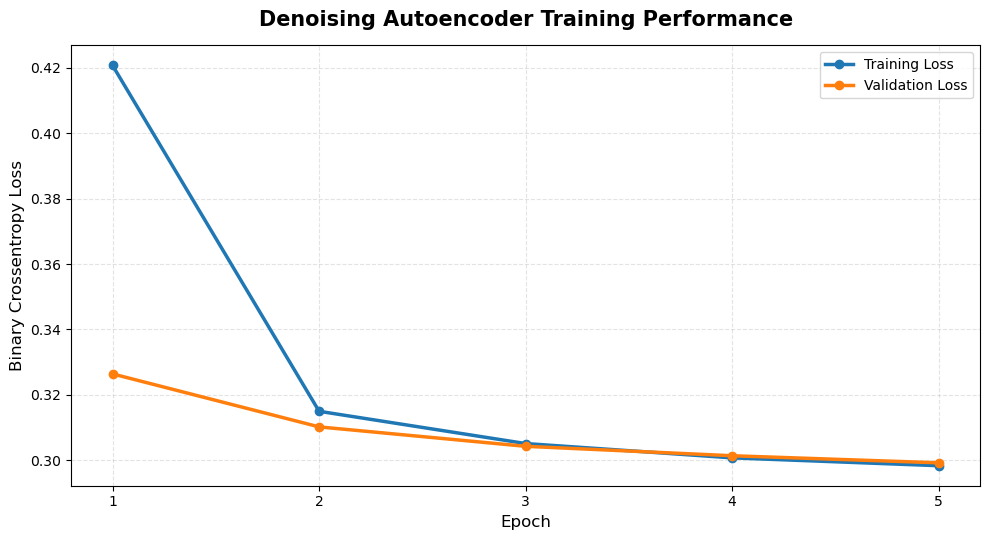

Final training loss: 0.2983
Final validation loss: 0.2992


In [9]:
# ============================================================
# Step 9: Plot Training and Validation Loss
# ============================================================

history_df = pd.DataFrame(denoising_history.history)
history_df["epoch"] = range(1, len(history_df) + 1)

plt.figure(figsize=(10, 5.5))

plt.plot(
    history_df["epoch"],
    history_df["loss"],
    marker="o",
    linewidth=2.5,
    label="Training Loss"
)

plt.plot(
    history_df["epoch"],
    history_df["val_loss"],
    marker="o",
    linewidth=2.5,
    label="Validation Loss"
)

plt.title(
    "Denoising Autoencoder Training Performance",
    fontsize=15,
    fontweight="bold",
    pad=14
)

plt.xlabel("Epoch", fontsize=12)
plt.ylabel("Binary Crossentropy Loss", fontsize=12)
plt.xticks(history_df["epoch"])
plt.grid(True, linestyle="--", alpha=0.35)
plt.legend(fontsize=10)
plt.tight_layout()
plt.show()

print("Final training loss:", round(history_df["loss"].iloc[-1], 4))
print("Final validation loss:", round(history_df["val_loss"].iloc[-1], 4))

### Training Performance — Conclusion

The loss curve shows whether the model improved during training.

If both training and validation loss decrease, the model is learning to reconstruct clean images from noisy inputs.

If validation loss stays close to training loss, the model is not strongly overfitting.

## 9. Generate Denoised Images

After training, we use the model on the final test set.

The test set was not used for training or validation.

The model receives:

`test_noisy`

and predicts:

`denoised_images`

We then compare these predictions with:

`test_clean`

In [10]:
# ============================================================
# Step 10: Generate Denoised Images on Test Set
# ============================================================

denoised_images = denoising_autoencoder.predict(
    test_noisy,
    batch_size=128,
    verbose=1
)

print("Test noisy shape:", test_noisy.shape)
print("Denoised image shape:", denoised_images.shape)
print("Test clean shape:", test_clean.shape)

16/16 ━━━━━━━━━━━━━━━━━━━━ 1s 47ms/step
Test noisy shape: (2000, 28, 28, 1)
Denoised image shape: (2000, 28, 28, 1)
Test clean shape: (2000, 28, 28, 1)


## 10. Compare Clean, Noisy, and Denoised Images

We now compare three versions of the same image:

| Row | Meaning |
|---|---|
| **Clean** | Original target image |
| **Noisy** | Corrupted input image |
| **Denoised** | Model output |

### Theory connection

If the model learned well, the denoised image should be closer to the clean image than the noisy image.

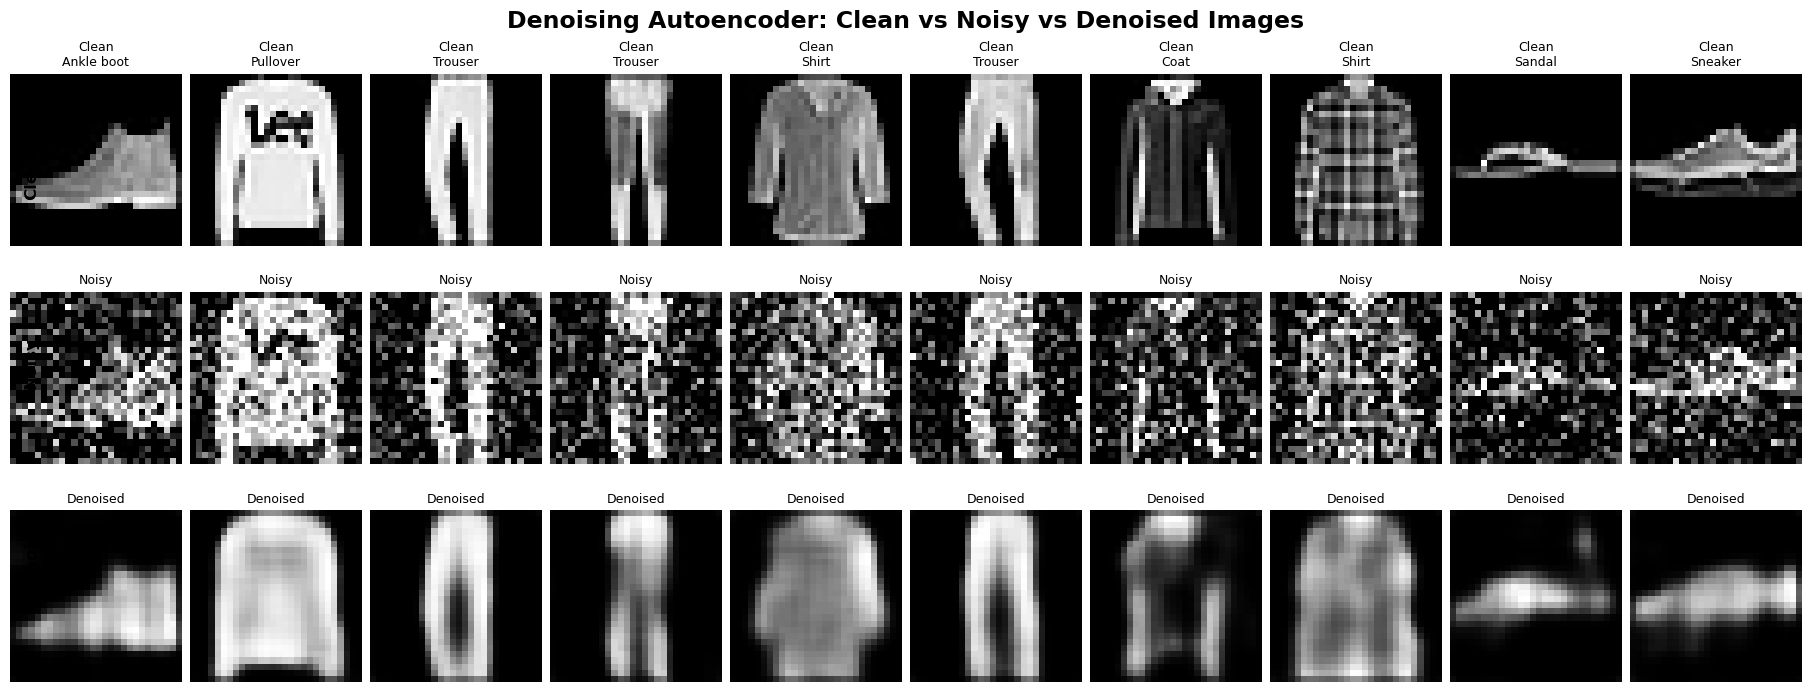

In [11]:
# ============================================================
# Step 11: Visualise Clean vs Noisy vs Denoised Images
# ============================================================

num_images = 10

clean_samples = test_clean[:num_images]
noisy_samples = test_noisy[:num_images]
denoised_samples = denoised_images[:num_images]
sample_labels = test_labels[:num_images]

fig, axes = plt.subplots(
    nrows=3,
    ncols=num_images,
    figsize=(18, 7),
    constrained_layout=True
)

fig.suptitle(
    "Denoising Autoencoder: Clean vs Noisy vs Denoised Images",
    fontsize=17,
    fontweight="bold"
)

for i in range(num_images):
    axes[0, i].imshow(clean_samples[i].squeeze(), cmap="gray")
    axes[0, i].set_title(f"Clean\n{class_names[sample_labels[i]]}", fontsize=9)
    axes[0, i].axis("off")

for i in range(num_images):
    axes[1, i].imshow(noisy_samples[i].squeeze(), cmap="gray")
    axes[1, i].set_title("Noisy", fontsize=9)
    axes[1, i].axis("off")

for i in range(num_images):
    axes[2, i].imshow(denoised_samples[i].squeeze(), cmap="gray")
    axes[2, i].set_title("Denoised", fontsize=9)
    axes[2, i].axis("off")

fig.text(0.01, 0.76, "Clean", fontsize=12, fontweight="bold", rotation=90, va="center")
fig.text(0.01, 0.49, "Noisy", fontsize=12, fontweight="bold", rotation=90, va="center")
fig.text(0.01, 0.22, "Denoised", fontsize=12, fontweight="bold", rotation=90, va="center")

plt.show()

## 11. Calculate Reconstruction Error

We calculate Mean Squared Error between:

| Comparison | Meaning |
|---|---|
| `test_clean` vs `test_noisy` | Error before denoising |
| `test_clean` vs `denoised_images` | Error after denoising |

If the model works, the denoised error should be lower than the noisy error.

In [12]:
# ============================================================
# Step 12: Calculate Denoising Reconstruction Error
# ============================================================

# Error before denoising
noisy_mse = np.mean(
    np.square(test_clean - test_noisy),
    axis=(1, 2, 3)
)

# Error after denoising
denoised_mse = np.mean(
    np.square(test_clean - denoised_images),
    axis=(1, 2, 3)
)

mse_summary = pd.DataFrame({
    "Version": ["Noisy Input", "Denoised Output"],
    "Average MSE vs Clean Image": [
        noisy_mse.mean(),
        denoised_mse.mean()
    ],
    "Minimum MSE": [
        noisy_mse.min(),
        denoised_mse.min()
    ],
    "Maximum MSE": [
        noisy_mse.max(),
        denoised_mse.max()
    ]
})

mse_summary_rounded = mse_summary.copy()
numeric_cols = mse_summary_rounded.columns.drop("Version")
mse_summary_rounded[numeric_cols] = mse_summary_rounded[numeric_cols].round(6)

mse_summary_rounded

,Version,Average MSE vs Clean Image,Minimum MSE,Maximum MSE
0,Noisy Input,0.068499,0.049008,0.087545
1,Denoised Output,0.018045,0.004797,0.073331


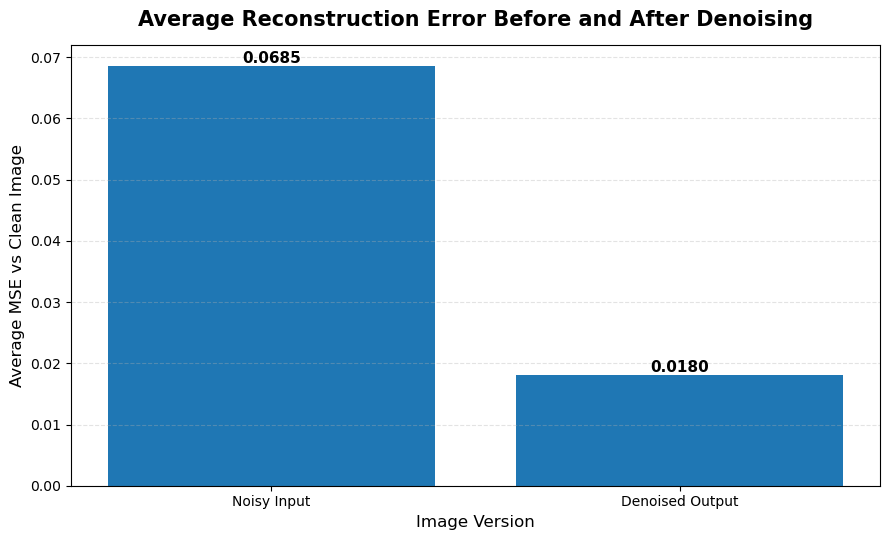

Denoising reduced average reconstruction error by 73.66%.


In [13]:
# ============================================================
# Step 13: Visualise MSE Before and After Denoising
# ============================================================

plt.figure(figsize=(9, 5.5))

bars = plt.bar(
    mse_summary_rounded["Version"],
    mse_summary_rounded["Average MSE vs Clean Image"]
)

for bar in bars:
    height = bar.get_height()
    plt.text(
        bar.get_x() + bar.get_width() / 2,
        height,
        f"{height:.4f}",
        ha="center",
        va="bottom",
        fontsize=11,
        fontweight="bold"
    )

plt.title(
    "Average Reconstruction Error Before and After Denoising",
    fontsize=15,
    fontweight="bold",
    pad=14
)

plt.ylabel("Average MSE vs Clean Image", fontsize=12)
plt.xlabel("Image Version", fontsize=12)
plt.grid(axis="y", linestyle="--", alpha=0.35)
plt.tight_layout()
plt.show()

improvement = (
    (noisy_mse.mean() - denoised_mse.mean()) / noisy_mse.mean()
) * 100

print(f"Denoising reduced average reconstruction error by {improvement:.2f}%.")

## Denoising Autoencoder — Final Conclusion

In this supplementary notebook, we built a convolutional denoising autoencoder on Fashion-MNIST.

### What was done

- Loaded Fashion-MNIST images
- Normalised pixel values from **0–255** to **0–1**
- Added controlled Gaussian noise
- Created proper train, validation, and test splits
- Built a convolutional denoising autoencoder
- Trained the model using:

`train_noisy → train_clean`

- Generated denoised images from unseen test data
- Compared clean, noisy, and denoised images
- Calculated reconstruction error before and after denoising

### Key learning

A denoising autoencoder does not simply copy the input.

It learns to remove random corruption and recover the important structure of the image.

The final MSE comparison shows whether the denoised output is closer to the clean image than the noisy input.

### Final takeaway

Denoising autoencoders are useful when data contains noise but the underlying structure is still meaningful.

They can be applied to image denoising, sensor cleaning, ECG signal cleaning, anomaly detection, and robust feature learning.